In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

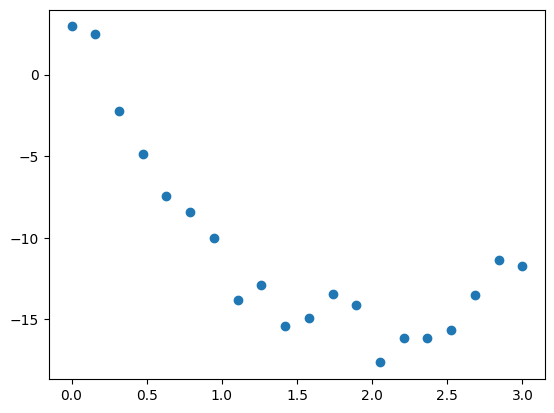

In [5]:
x_data = np.array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])
y_data = np.array([  2.95258285,   2.49719803,  -2.1984975 ,  -4.88744346,
        -7.41326345,  -8.44574157, -10.01878504, -13.83743553,
       -12.91548145, -15.41149046, -14.93516299, -13.42514157,
       -14.12110495, -17.6412464 , -16.1275509 , -16.11533771,
       -15.66076021, -13.48938865, -11.33918701, -11.70467566])
plt.scatter(x_data, y_data)

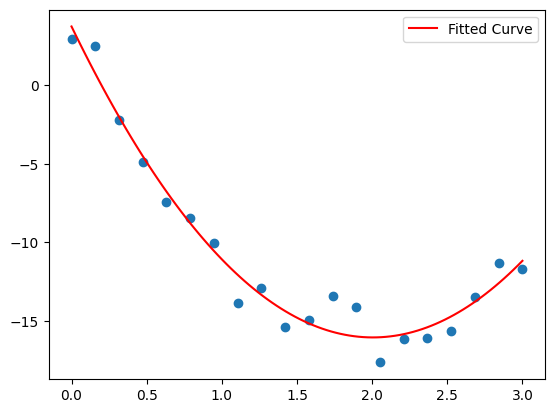

In [6]:
def model_f(x, a, b, c):
    return a * (x - b)**2 + c

popt, pcov = curve_fit(model_f, x_data, y_data, p0=[3, 2, -16])
a_opt, b_opt, c_opt = popt

x_model = np.linspace(min(x_data), max(x_data), 100)
y_model = model_f(x_model, a_opt, b_opt, c_opt)
plt.plot(x_model, y_model, color='red', label='Fitted Curve')
plt.scatter(x_data, y_data)
plt.legend()
plt.show()

In [8]:
def model_f(x, a, b, c, d):
    return a*(x-b)**2 + c + d*0.0001*np.cos(x)

popt, pcov = curve_fit(model_f, x_data, y_data, p0=[3, 2, -16, 1])
popt, pcov

(array([ 4.90444516e+00,  2.05365370e+00, -1.62540300e+01, -5.96808551e+03]),
 array([[ 1.45024135e-01, -4.03732021e-02,  4.08920570e-02,
          3.05314240e+03],
        [-4.03732021e-02,  7.20536817e-02, -3.07488355e-01,
         -8.46750670e+03],
        [ 4.08920570e-02, -3.07488355e-01,  1.52776281e+00,
          3.78842378e+04],
        [ 3.05314240e+03, -8.46750670e+03,  3.78842378e+04,
          1.03326871e+09]]))

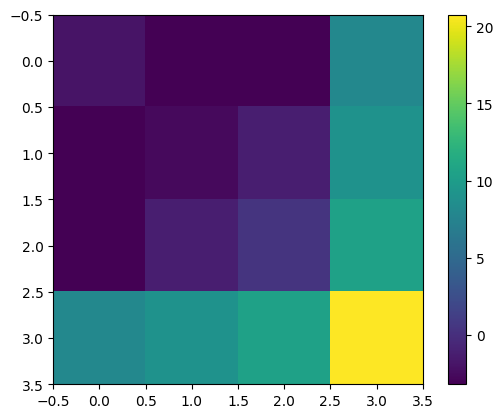

In [9]:
plt.imshow(np.log(np.abs(pcov)))
plt.colorbar()
plt.show()

GAUSSIAN CURVE FITTING:

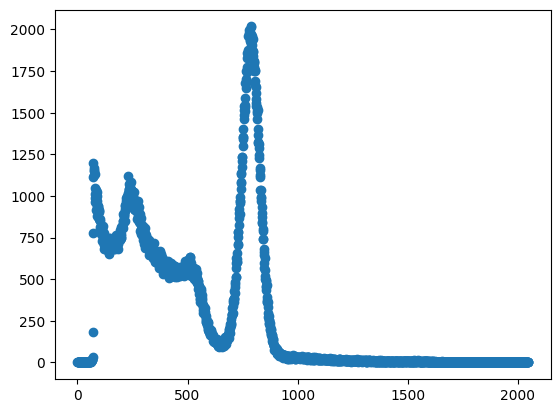

In [17]:
import pandas as pd

file = pd.read_csv('curvefite1.csv')
x_stuff = file.Channel
y_stuff = file.Cs137
plt.scatter(x_stuff, y_stuff)

In [15]:
def gauss_f(x, A, mu, sig):
    return A*np.exp(-(x-mu)**2 / sig**2)

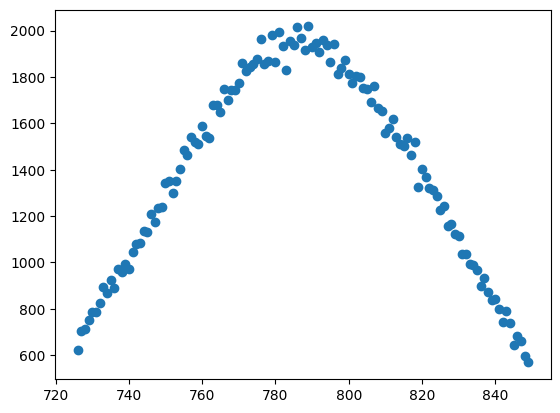

In [24]:
x_data = x_stuff[(x_stuff>725) & (x_stuff<850)]
y_data = y_stuff[(x_stuff>725) & (x_stuff<850)]
plt.scatter(x_data, y_data)

In [26]:
popt, pcov = curve_fit(gauss_f, x_data, y_data, p0=[2000, 790, 100])
popt

array([1939.55511234,  786.33851872,   57.78717156])

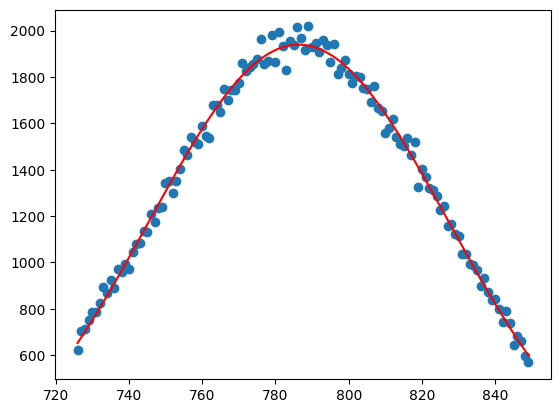

In [30]:
A_opt, mu_opt, sig_opt = popt

x_model = np.linspace(min(x_data), max(x_data), 1000)
y_model = gauss_f(x_model, A_opt, mu_opt, sig_opt)

plt.scatter(x_data, y_data)
plt.plot(x_model, y_model, color='r')
plt.show()

In [31]:
pcov

array([[ 3.25194170e+01,  1.08036572e-02, -9.64136240e-01],
       [ 1.08036572e-02,  2.07414848e-02, -1.14103388e-03],
       [-9.64136240e-01, -1.14103388e-03,  6.98390359e-02]])

In [36]:
#GIVES error on parameters
np.sqrt(np.diag(pcov))

array([5.70257985, 0.14401904, 0.26427076])

ERRORS checking: 

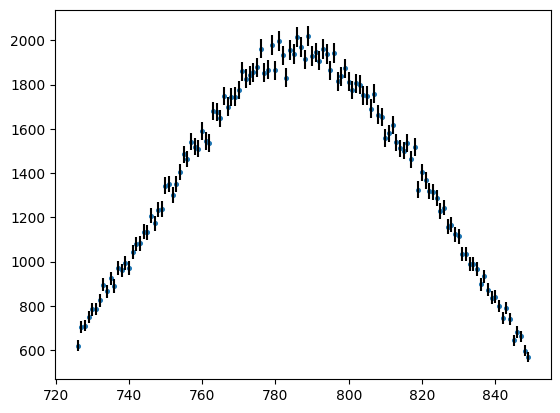

In [41]:
yerr_data = np.sqrt(y_data)

plt.errorbar(x_data, y_data, yerr_data, ls='', color='k')
plt.scatter(x_data, y_data, s=7)
plt.show()

In [45]:
popt, pcov = curve_fit(gauss_f, x_data, y_data, sigma=yerr_data, p0=[2000, 780, 60])


array([[ 3.90690300e+01,  1.96114206e-02, -9.82846887e-01],
       [ 1.96114206e-02,  1.65814874e-02, -1.59278730e-03],
       [-9.82846887e-01, -1.59278730e-03,  5.25879665e-02]])

STANDARDIZATION

In [48]:
r_data, V_data = np.loadtxt('curvefite2.txt')

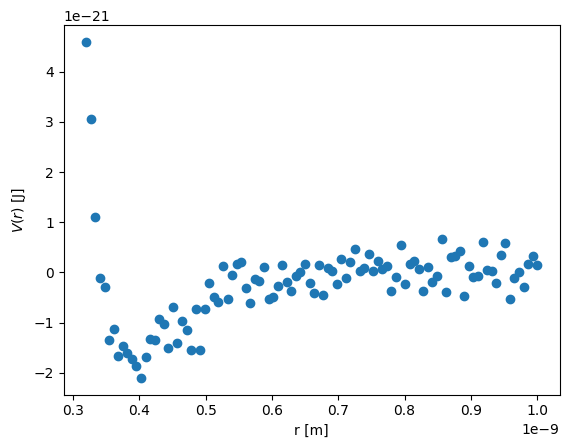

In [51]:
plt.scatter(r_data, V_data)
plt.xlabel('r [m]')
plt.ylabel('$V(r)$ [J]')
plt.show()

STANDARDIZING

In [52]:
r_data*=1e9
V_data/=1.38e-23

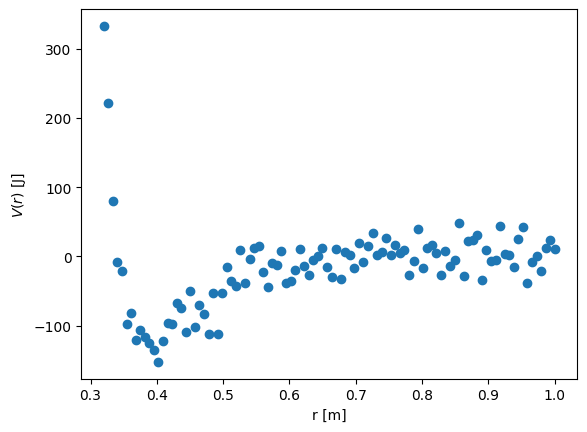

In [53]:
plt.scatter(r_data, V_data)
plt.xlabel('r [m]')
plt.ylabel('$V(r)$ [J]')
plt.show()

In [57]:
def model_f(r, sigma, epsilon):
    return 4*epsilon*((sigma/r)**12 - (sigma/r)**6)

eps_guess = -120  #value of min V(r) = -epsilon
sig_guess = 2**(-1/6) * 0.4 #value of min r = 2**(1/6) * sigma

popt, pcov = curve_fit(model_f, r_data, V_data, p0=[sig_guess, eps_guess])
sig_opt, eps_opt = popt

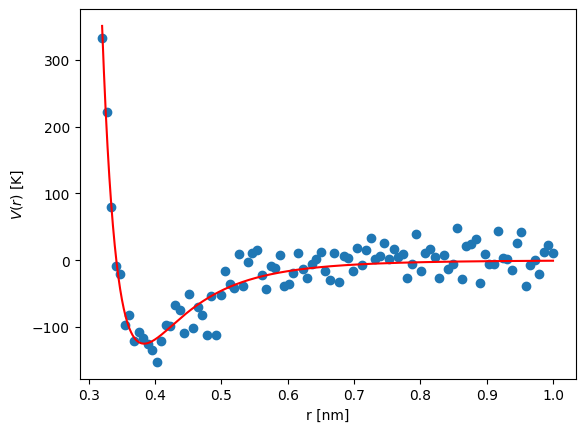

In [59]:
x_model = np.linspace(min(r_data), max(r_data), 1000)
y_model = model_f(x_model, sig_opt, eps_opt)
plt.plot(x_model, y_model, color='r')
plt.scatter(r_data, V_data)
plt.xlabel('r [nm]')
plt.ylabel('$V(r)$ [K]')
plt.show()